# AIML Lab 2 - Exploratory Data Analysis of Healthcare Data

**Dataset:** Pima Indians Diabetes (768 patient records)

EDA on a diabetes dataset to understand patient health trends, find risk
factors, check data quality, and study relationships between health parameters
before any modelling.

**Steps covered:** load -> inspect structure -> missing values -> duplicates ->
summary statistics -> univariate -> bivariate -> multivariate -> outlier detection
-> correlation -> target analysis -> key findings.

## 1. Load the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Understand the dataset structure

Check the number of rows/columns and the data type of each column.

In [2]:
print("Shape (rows, columns):", df.shape)
print()
df.info()

Shape (rows, columns): (768, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
# The target column 'Outcome': 1 = diabetic, 0 = not diabetic
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 3. Handle missing values

There are no `NaN`s in this dataset, but several columns use **0** to mean a
missing reading (a Glucose, BloodPressure, SkinThickness, Insulin or BMI of 0
is medically impossible). We treat those zeros as missing.

In [4]:
print("Explicit NaN values per column:")
print(df.isnull().sum())

Explicit NaN values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [5]:
zero_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("Number of 0s (hidden missing values) per column:")
print((df[zero_missing] == 0).sum())

Number of 0s (hidden missing values) per column:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [6]:
# Treat 0 as missing, then impute with the column median
df_clean = df.copy()
df_clean[zero_missing] = df_clean[zero_missing].replace(0, np.nan)
df_clean[zero_missing] = df_clean[zero_missing].fillna(df_clean[zero_missing].median())

print("Missing values after imputation:", int(df_clean.isnull().sum().sum()))

Missing values after imputation: 0


## 4. Remove duplicates

In [7]:
dupes = df_clean.duplicated().sum()
print("Duplicate rows found:", dupes)
df_clean = df_clean.drop_duplicates()
print("Shape after dropping duplicates:", df_clean.shape)

Duplicate rows found: 0
Shape after dropping duplicates: (768, 9)


## 5. Summary statistics

Descriptive statistics for the numeric features after cleaning.

In [8]:
df_clean.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.0,121.66,30.44,44.00,99.75,117.00,140.25,199.00
BloodPressure,768.0,72.39,12.10,24.00,64.00,72.00,80.00,122.00
SkinThickness,768.0,29.11,8.79,7.00,25.00,29.00,32.00,99.00
Insulin,768.0,140.67,86.38,14.00,121.50,125.00,127.25,846.00
BMI,768.0,32.46,6.88,18.20,27.50,32.30,36.60,67.10
DiabetesPedigreeFunction,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


## 6. Univariate analysis

Look at one feature at a time - histograms for the numeric distributions,
a boxplot for a single feature, and a count/pie for the categorical target.

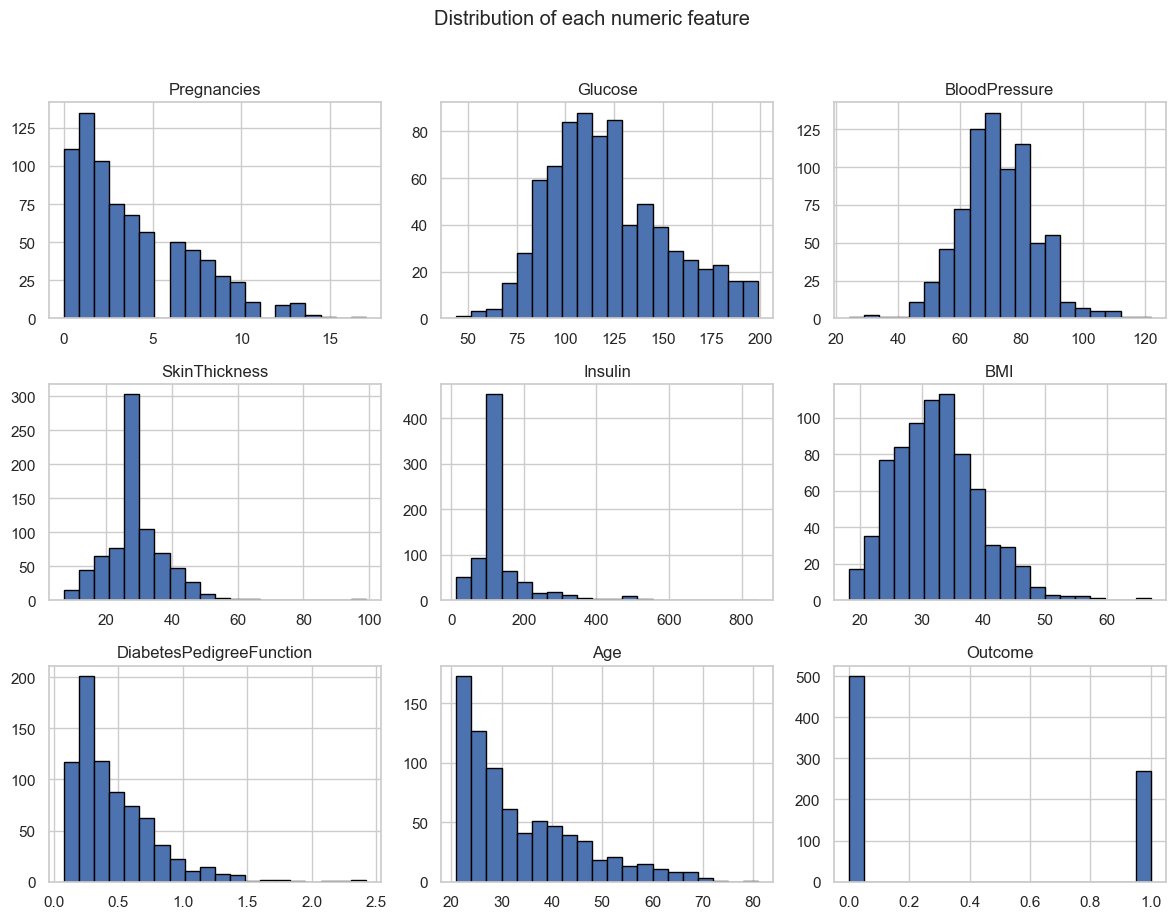

In [9]:
df_clean.hist(figsize=(12, 9), bins=20, edgecolor="black")
plt.suptitle("Distribution of each numeric feature", y=1.02)
plt.tight_layout()
plt.show()

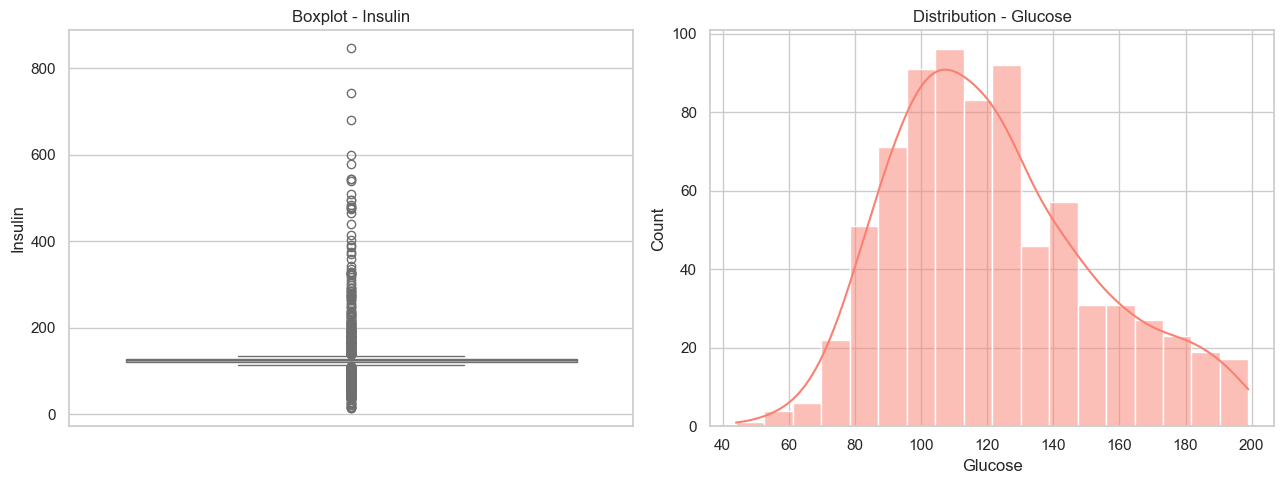

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(y=df_clean["Insulin"], ax=ax[0], color="skyblue")
ax[0].set_title("Boxplot - Insulin")
sns.histplot(df_clean["Glucose"], kde=True, ax=ax[1], color="salmon")
ax[1].set_title("Distribution - Glucose")
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21764\3488537734.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts.values, ax=ax[0], palette="Set2")


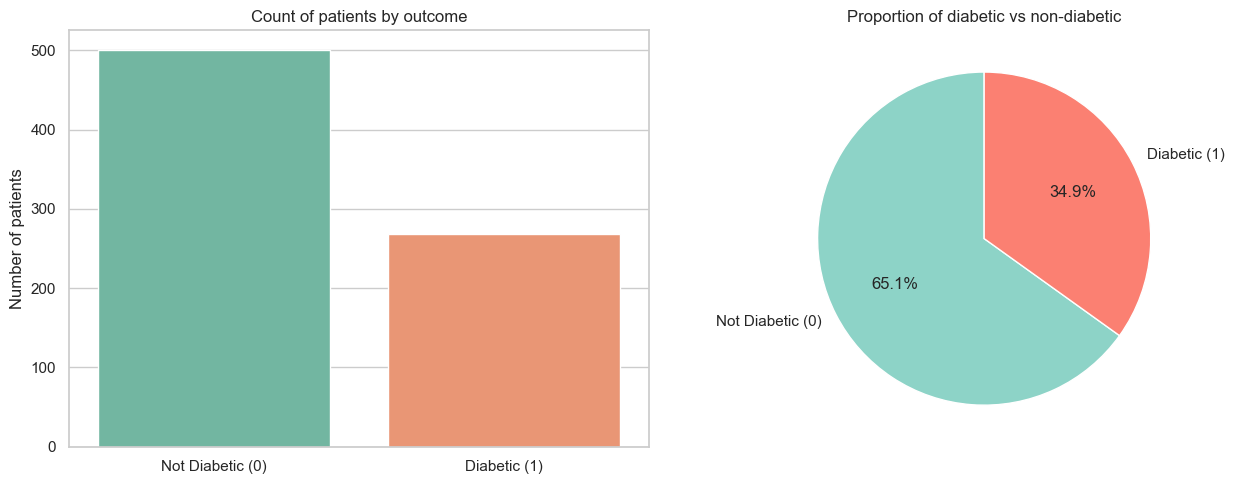

In [11]:
# Target variable as a bar chart and a pie chart
counts = df_clean["Outcome"].value_counts().sort_index()
labels = ["Not Diabetic (0)", "Diabetic (1)"]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=labels, y=counts.values, ax=ax[0], palette="Set2")
ax[0].set_title("Count of patients by outcome")
ax[0].set_ylabel("Number of patients")
ax[1].pie(counts.values, labels=labels, autopct="%1.1f%%",
          colors=["#8dd3c7", "#fb8072"], startangle=90)
ax[1].set_title("Proportion of diabetic vs non-diabetic")
plt.tight_layout()
plt.show()

## 7. Bivariate analysis

Study relationships between two variables - how features relate to the diabetes
outcome, and to each other.

          Not Diabetic  Diabetic
AgeGroup                        
20-29              327        90
30-39               81        76
40-49               49        64
50-59               23        31
60+                 20         7


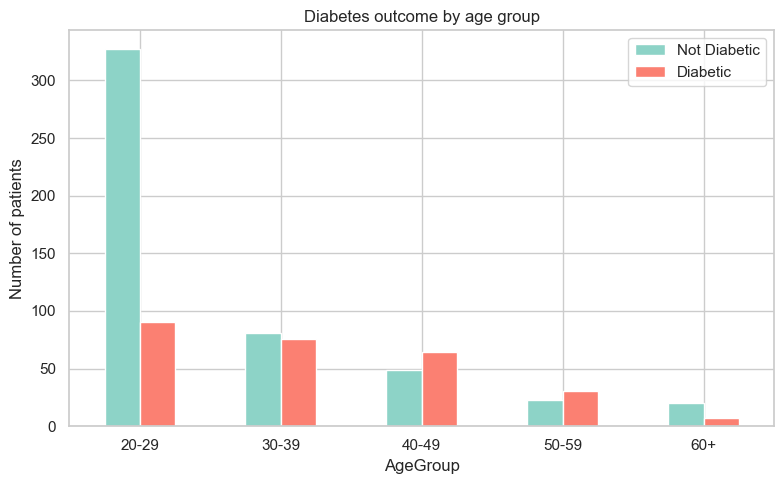

In [12]:
# Age group vs diabetes: which age group has the most diabetic patients?
df_clean["AgeGroup"] = pd.cut(df_clean["Age"], bins=[20, 30, 40, 50, 60, 100],
                              labels=["20-29", "30-39", "40-49", "50-59", "60+"])
ct = pd.crosstab(df_clean["AgeGroup"], df_clean["Outcome"])
ct.columns = ["Not Diabetic", "Diabetic"]
print(ct)

ct.plot(kind="bar", stacked=False, color=["#8dd3c7", "#fb8072"])
plt.title("Diabetes outcome by age group")
plt.ylabel("Number of patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

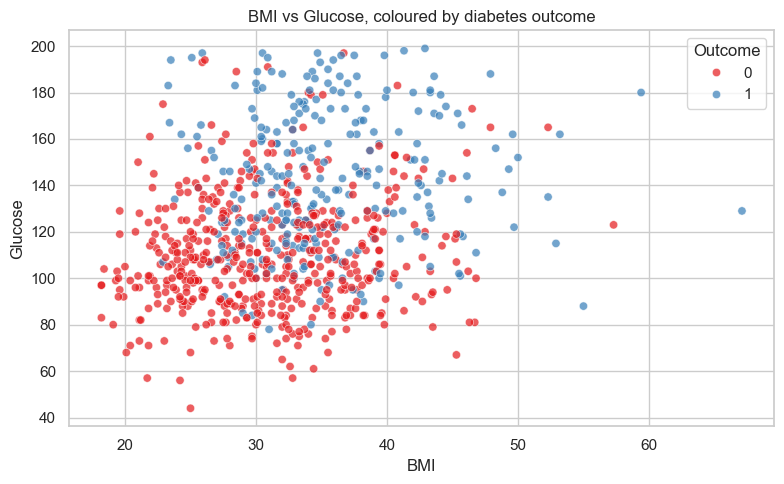

In [13]:
# Is there a link between BMI and blood sugar level?
sns.scatterplot(data=df_clean, x="BMI", y="Glucose", hue="Outcome",
                palette="Set1", alpha=0.7)
plt.title("BMI vs Glucose, coloured by diabetes outcome")
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21764\4001372230.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Outcome", y=col, ax=a, palette="Set2")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21764\4001372230.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(["Not Diabetic", "Diabetic"])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21764\4001372230.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Outcome", y=col, ax=a, palette="Set2")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21764\4001372230.py:6: UserWarning: set_ticklabels() should only 

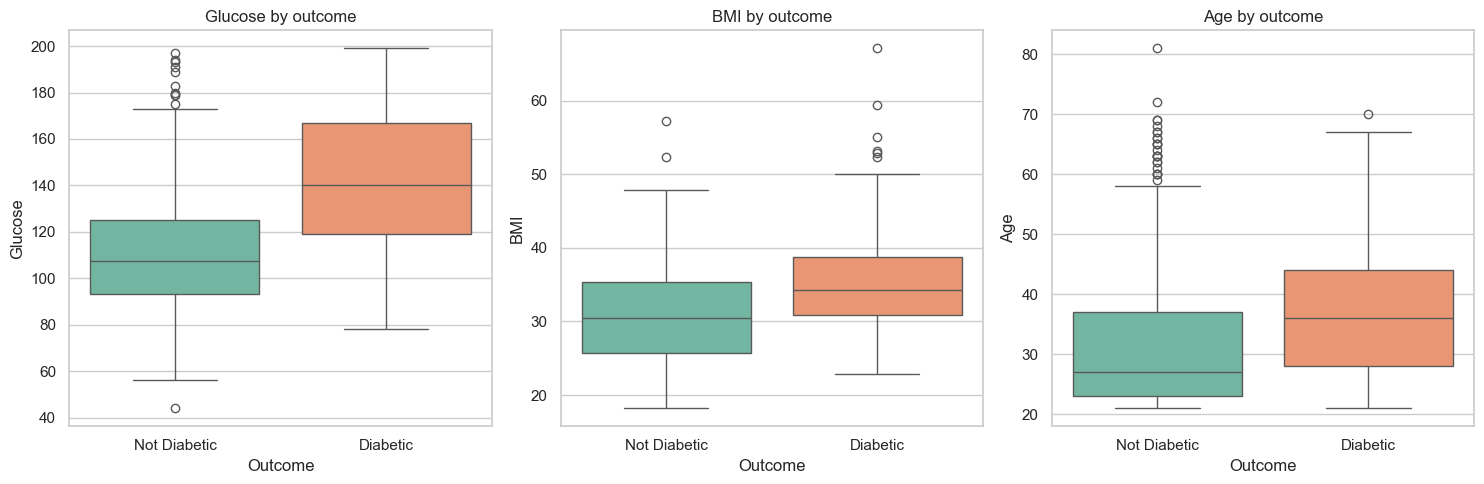

In [14]:
# How do key features differ between diabetic and non-diabetic patients?
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, col in zip(ax, ["Glucose", "BMI", "Age"]):
    sns.boxplot(data=df_clean, x="Outcome", y=col, ax=a, palette="Set2")
    a.set_title(f"{col} by outcome")
    a.set_xticklabels(["Not Diabetic", "Diabetic"])
plt.tight_layout()
plt.show()

## 8. Multivariate analysis

Interactions between several variables at once using a pair plot.

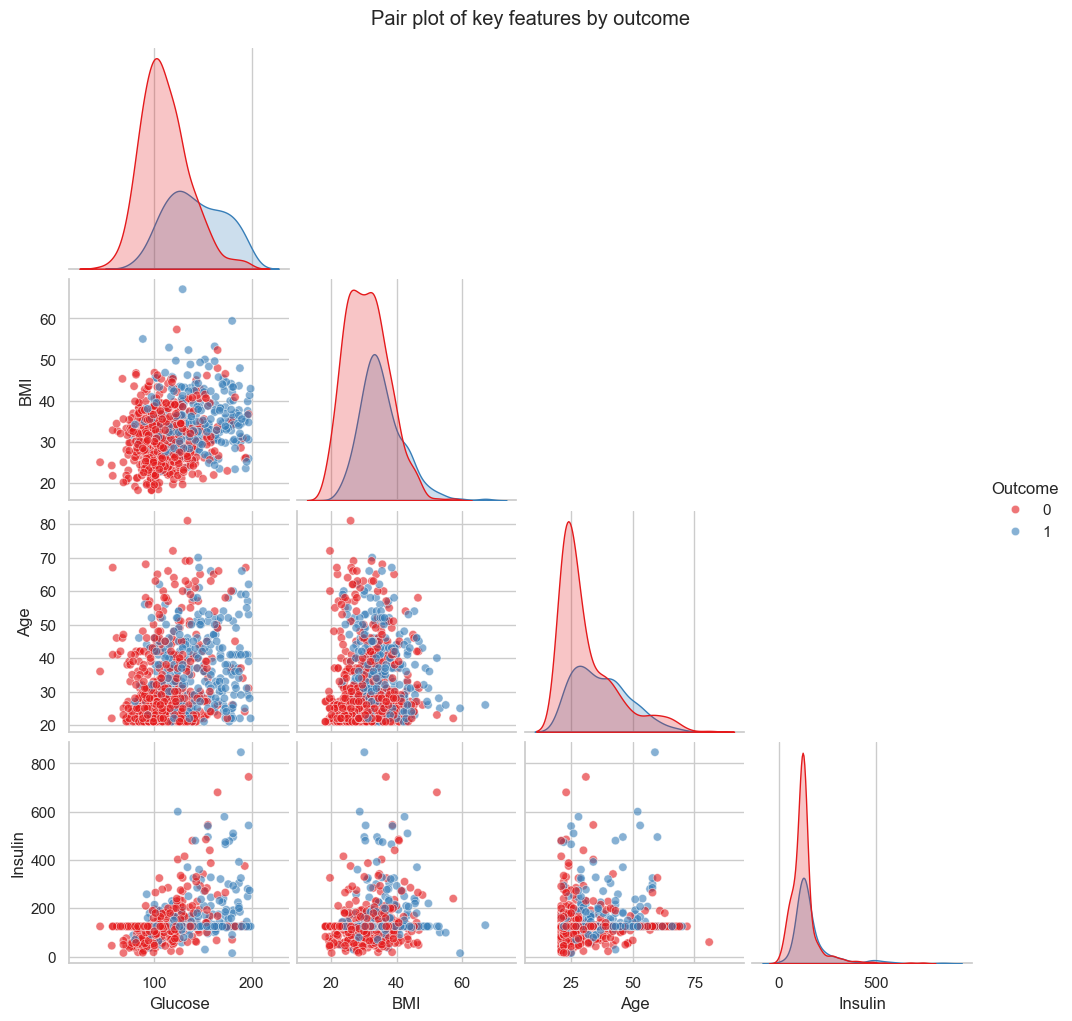

In [15]:
subset = ["Glucose", "BMI", "Age", "Insulin", "Outcome"]
sns.pairplot(df_clean[subset], hue="Outcome", palette="Set1",
             corner=True, plot_kws={"alpha": 0.6})
plt.suptitle("Pair plot of key features by outcome", y=1.02)
plt.show()

## 9. Outlier detection

Use the IQR rule to count outliers in each numeric feature and visualise them
with boxplots.

In [16]:
num_cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

def count_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lower) | (s > upper)).sum()

outlier_counts = {c: int(count_outliers(df_clean[c])) for c in num_cols}
print("Outliers per feature (IQR rule):")
for c, n in outlier_counts.items():
    print(f"  {c:<26} {n}")

Outliers per feature (IQR rule):
  Pregnancies                4
  Glucose                    0
  BloodPressure              14
  SkinThickness              87
  Insulin                    346
  BMI                        8
  DiabetesPedigreeFunction   29
  Age                        9


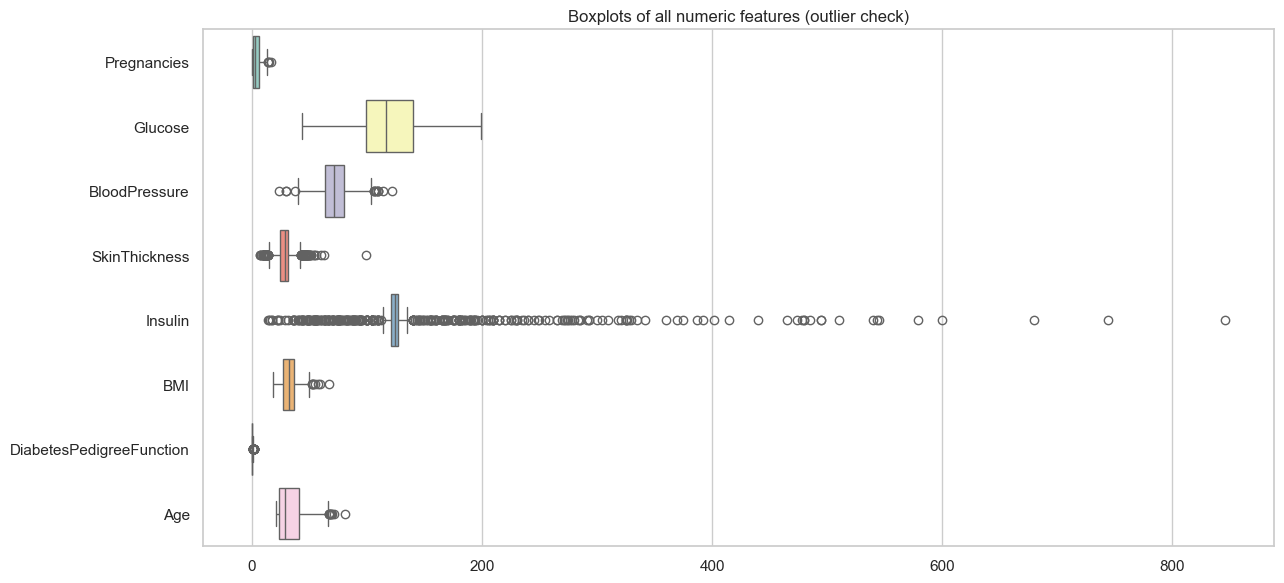

In [17]:
plt.figure(figsize=(13, 6))
sns.boxplot(data=df_clean[num_cols], orient="h", palette="Set3")
plt.title("Boxplots of all numeric features (outlier check)")
plt.tight_layout()
plt.show()

## 10. Correlation analysis

Correlation between numeric variables, visualised as a heatmap.

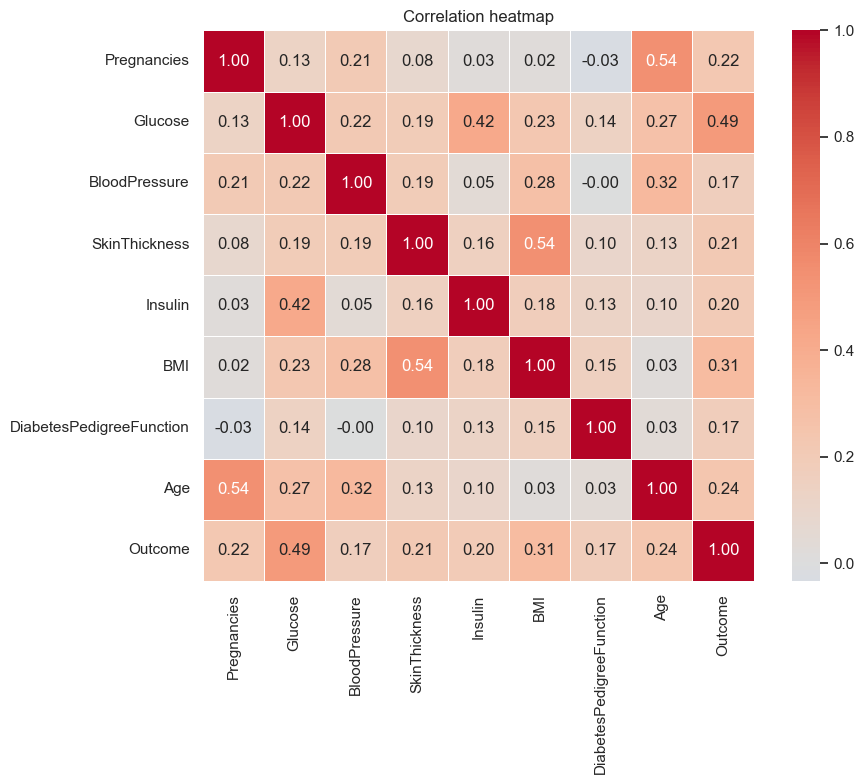

In [18]:
corr = df_clean[num_cols + ["Outcome"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

In [19]:
# Which features correlate most with the diabetes outcome?
print("Correlation with Outcome (sorted):")
print(corr["Outcome"].drop("Outcome").sort_values(ascending=False).round(3))

Correlation with Outcome (sorted):
Glucose                     0.493
BMI                         0.312
Age                         0.238
Pregnancies                 0.222
SkinThickness               0.215
Insulin                     0.204
DiabetesPedigreeFunction    0.174
BloodPressure               0.166
Name: Outcome, dtype: float64


## 11. Analyze the target variable

Check the class balance of the target.

In [20]:
balance = df_clean["Outcome"].value_counts()
pct = df_clean["Outcome"].value_counts(normalize=True) * 100
print("Class distribution:")
print(f"  Not Diabetic (0): {balance[0]}  ({pct[0]:.1f}%)")
print(f"  Diabetic     (1): {balance[1]}  ({pct[1]:.1f}%)")
print(f"\nImbalance ratio ~ {balance[0] / balance[1]:.2f} : 1 (non-diabetic : diabetic)")

Class distribution:
  Not Diabetic (0): 500  (65.1%)
  Diabetic     (1): 268  (34.9%)

Imbalance ratio ~ 1.87 : 1 (non-diabetic : diabetic)


## 12. Key findings

- **Hidden missing data:** several columns (Insulin, SkinThickness, Glucose,
  BloodPressure, BMI) used `0` to encode missing readings - Insulin had by far
  the most. These were imputed with the median.
- **Class imbalance:** about **65% non-diabetic vs 35% diabetic** (~1.87 : 1),
  which is worth accounting for when modelling.
- **Strongest predictors:** **Glucose** correlates most with the outcome,
  followed by **BMI** and **Age** - consistent with medical expectations.
- **BMI vs Glucose:** diabetic patients cluster toward higher glucose and
  higher BMI values.
- **Age effect:** the proportion of diabetic patients rises in the middle age
  groups compared with the youngest (20-29) group.
- **Outliers:** Insulin and SkinThickness carry the most extreme values even
  after cleaning, so they may need capping before modelling.